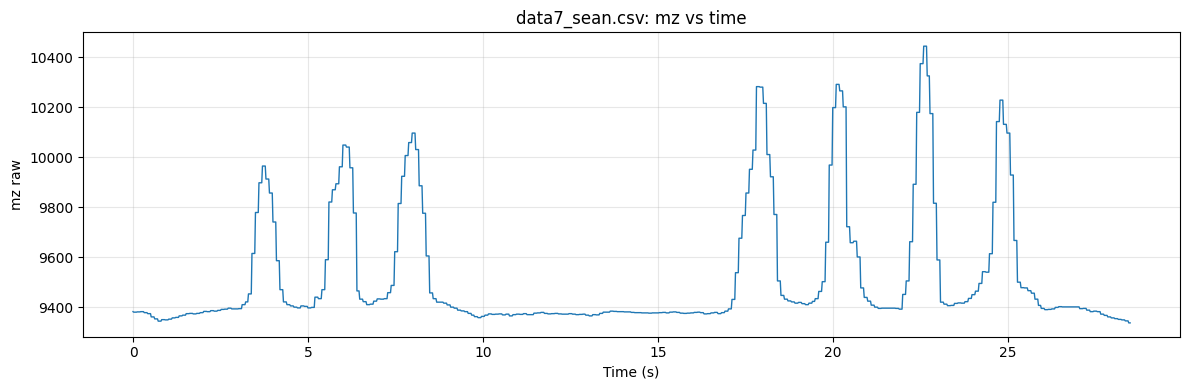

In [1]:
# data7_sean.csv: timestamp vs mz only
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

path = Path("data7_sean.csv")
rows = []
with path.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        rows.append({
            "timestamp_ms": float(parts[1]),
            "mz": float(parts[4]),
        })

df7 = pd.DataFrame(rows)
df7["time_s"] = (df7["timestamp_ms"] - df7["timestamp_ms"].iloc[0]) / 1000.0

plt.figure(figsize=(12, 4))
plt.plot(df7["time_s"], df7["mz"], linewidth=1.0)
plt.xlabel("Time (s)")
plt.ylabel("mz raw")
plt.title("data7_sean.csv: mz vs time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


""


startup b0 = 9365.53, events = 0


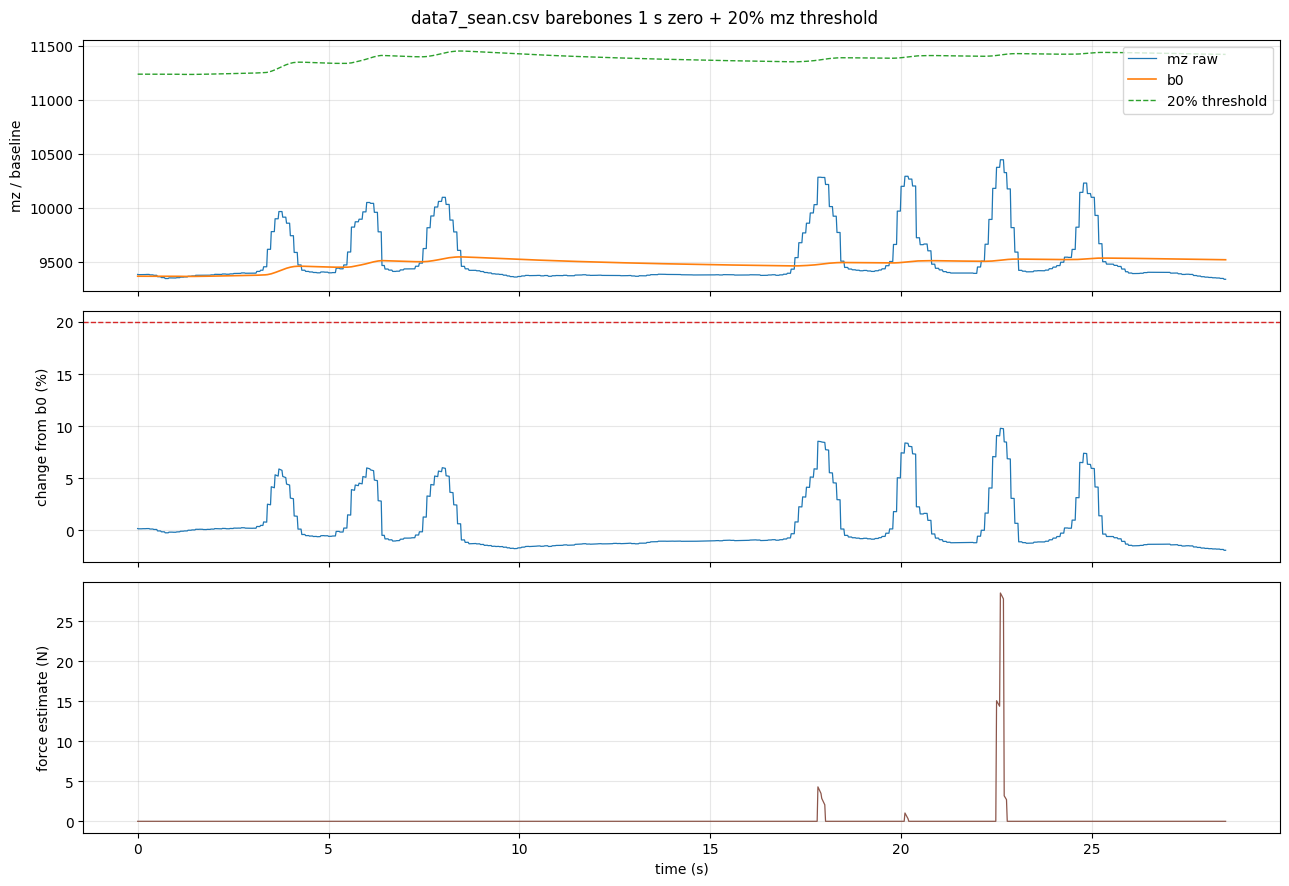

In [2]:
# Barebones zeroing detector for data7_sean.csv
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("data7_sean.csv")
STARTUP_ZERO_S = 1.0
THRESHOLD_FRAC = 0.20
REFRACTORY_MS = 50.0
SUSTAINED_CUTOFF_S = 2.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5
BASELINE_DISTANCE_MM = 10.0

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        rows.append({
            "seq": int(parts[0]),
            "timestamp_ms": float(parts[1]),
            "mx": float(parts[2]),
            "my": float(parts[3]),
            "mz": float(parts[4]),
        })

df = pd.DataFrame(rows)
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
df["abs_mz"] = df["mz"].abs()

startup = df[df["time_s"] <= STARTUP_ZERO_S]
b0 = startup["abs_mz"].mean()
threshold = b0 * (1.0 + THRESHOLD_FRAC)

state = "idle"
baseline_samples = []
load_start_t = None
last_release_t = -1e9
events = []

states = []
baselines = []
dev_fracs = []
r_diffs = []
forces = []

for row in df.itertuples(index=False):
    t = row.time_s
    abs_mz = row.abs_mz
    dev_frac = (abs_mz - b0) / b0 if b0 else 0.0

    r_diff = 0.0
    if abs_mz > 1.0 and b0 > 1.0 and abs_mz > b0:
        r_mm = BASELINE_DISTANCE_MM * (b0 / abs_mz) ** (1.0 / 3.0)
        r_diff = BASELINE_DISTANCE_MM - r_mm
    force_n = max(FORCE_SLOPE * r_diff + FORCE_INTERCEPT, 0.0) if r_diff > 0 else 0.0

    if state == "idle":
        can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
        if can_start and abs_mz >= threshold:
            state = "loaded"
            load_start_t = t
            baseline_samples = []
        else:
            baseline_samples.append(abs_mz)
            if t > STARTUP_ZERO_S and baseline_samples:
                b0 = sum(baseline_samples) / len(baseline_samples)
                threshold = b0 * (1.0 + THRESHOLD_FRAC)

    elif state == "loaded":
        if abs_mz < threshold:
            duration_s = t - load_start_t
            # Literal version of your note: releases before 2 s are labelled sustained.
            kind = "sustained" if duration_s < SUSTAINED_CUTOFF_S else "long_load"
            events.append({
                "start_s": load_start_t,
                "end_s": t,
                "duration_s": duration_s,
                "kind": kind,
            })
            state = "idle"
            last_release_t = t
            baseline_samples = [abs_mz]
            b0 = abs_mz
            threshold = b0 * (1.0 + THRESHOLD_FRAC)

    states.append(state)
    baselines.append(b0)
    dev_fracs.append(dev_frac)
    r_diffs.append(r_diff)
    forces.append(force_n)

df["state"] = states
df["b0"] = baselines
df["threshold"] = [b * (1.0 + THRESHOLD_FRAC) for b in baselines]
df["dev_frac"] = dev_fracs
df["r_diff_mm"] = r_diffs
df["force_n"] = forces

events_df = pd.DataFrame(events)
display(events_df)
print(f"startup b0 = {startup['abs_mz'].mean():.2f}, events = {len(events_df)}")

fig, axs = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axs[0].plot(df["time_s"], df["mz"], lw=0.9, label="mz raw")
axs[0].plot(df["time_s"], df["b0"], lw=1.2, label="b0")
axs[0].plot(df["time_s"], df["threshold"], lw=1.0, ls="--", label="20% threshold")
axs[0].set_ylabel("mz / baseline")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df["time_s"], df["dev_frac"] * 100.0, lw=0.9)
axs[1].axhline(THRESHOLD_FRAC * 100.0, color="C3", ls="--", lw=1.0)
axs[1].set_ylabel("change from b0 (%)")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df["time_s"], df["force_n"], lw=0.9, color="C5")
axs[2].set_ylabel("force estimate (N)")
axs[2].set_xlabel("time (s)")
axs[2].grid(True, alpha=0.3)

for event in events:
    color = "C2" if event["kind"] == "sustained" else "C1"
    for ax in axs:
        ax.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

fig.suptitle("data7_sean.csv barebones 1 s zero + 20% mz threshold")
plt.tight_layout()
plt.show()


,start_s,end_s,duration_s,kind
0,3.42,4.34,0.92,step
1,5.54,6.54,1.00,step
2,7.50,8.58,1.08,step
3,17.24,18.76,1.52,step
4,19.84,20.88,1.04,step
5,22.14,23.22,1.08,step
6,24.62,25.30,0.68,step


startup mean=9351.30, startup std=13.97, events=7, steps=7, sustained=0


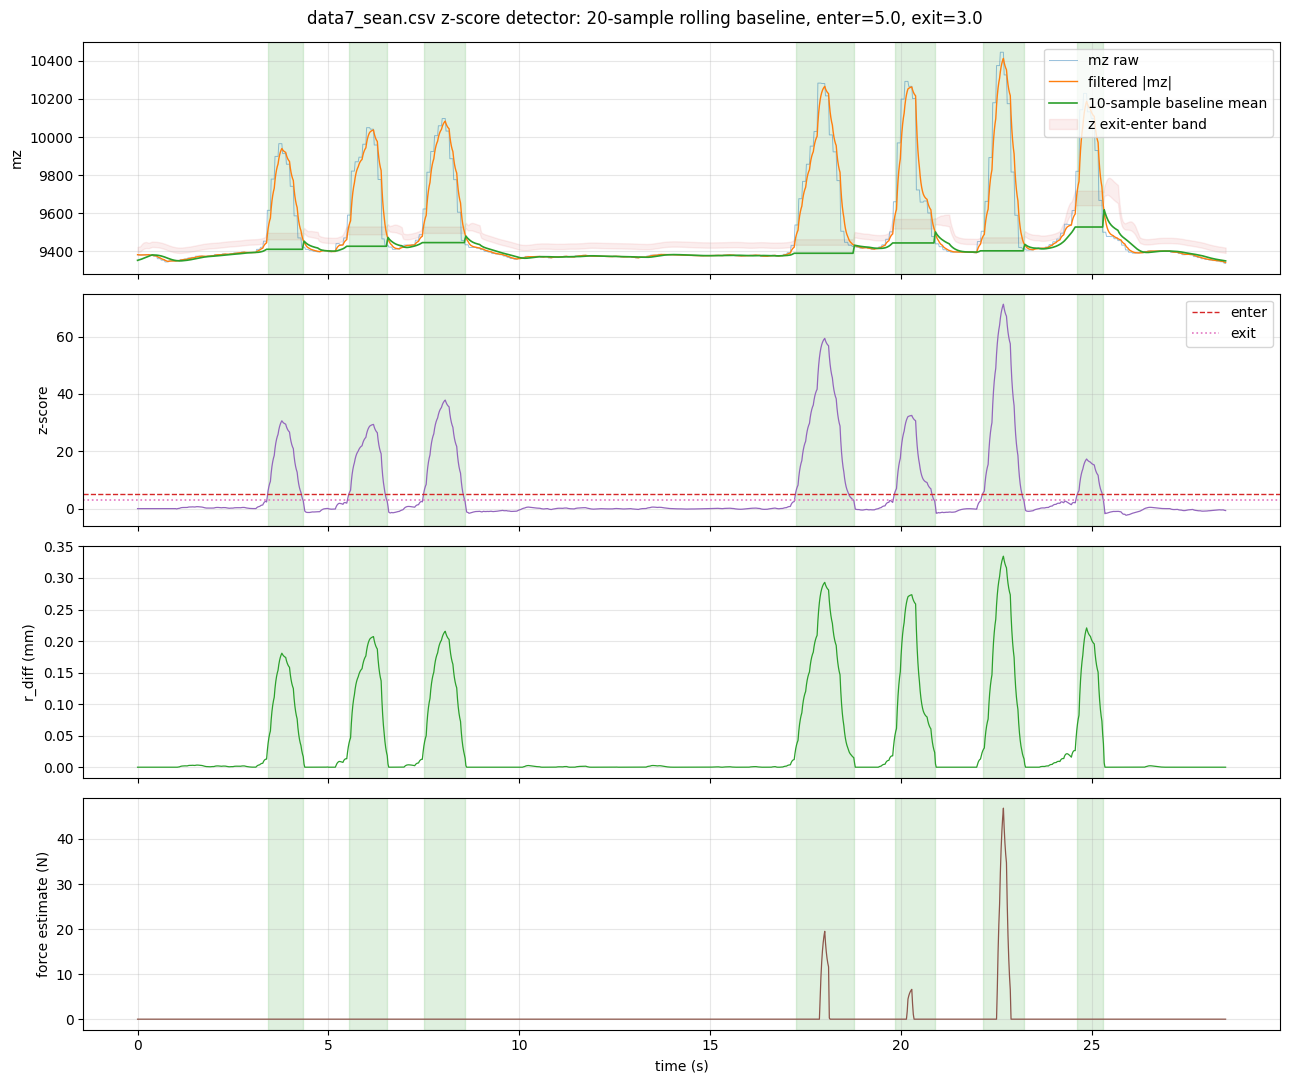

In [193]:
# Z-score detector experiment for data7_sean.csv with 10-sample rolling baseline
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("data7_sean.csv")
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 20
Z_ENTER = 5.0
Z_EXIT = 3.0
REFRACTORY_MS = 50.0
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5
BASELINE_DISTANCE_MM = 10.0

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        rows.append({
            "seq": int(parts[0]),
            "timestamp_ms": float(parts[1]),
            "mz": float(parts[4]),
        })

df = pd.DataFrame(rows)
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
df["abs_mz"] = df["mz"].abs()
df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

startup = df[df["time_s"] <= STARTUP_ZERO_S]
startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)


def window_stats(window):
    vals = pd.Series(list(window), dtype="float64")
    mean = vals.mean()
    std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
    # Keep the rolling mean responsive, but do not let z-score noise scale collapse.
    return mean, max(std, startup_std_floor)


def update_rolling_baseline(window, b):
    window.append(b)
    return window_stats(window)


baseline_mean, baseline_std = window_stats(baseline_window)
startup_mean = baseline_mean
startup_std = baseline_std

state = "idle"
load_start_t = None
last_release_t = -1e9
events = []

states = []
baseline_means = []
baseline_stds = []
z_scores = []
r_diffs = []
forces = []

for row in df.itertuples(index=False):
    t = row.time_s
    b = row.abs_mz_lpf

    # During startup, keep filling the same 10-sample rolling window.
    if t <= STARTUP_ZERO_S:
        baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        z = 0.0
        r_diff = 0.0
        force_n = 0.0
        states.append("zeroing")
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)
        r_diffs.append(r_diff)
        forces.append(force_n)
        continue

    z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

    r_diff = 0.0
    if b > 1.0 and baseline_mean > 1.0 and b > baseline_mean:
        r_mm = BASELINE_DISTANCE_MM * (baseline_mean / b) ** (1.0 / 3.0)
        r_diff = BASELINE_DISTANCE_MM - r_mm
    force_n = max(FORCE_SLOPE * r_diff + FORCE_INTERCEPT, 0.0) if r_diff > 0 else 0.0

    if state == "idle":
        can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
        if can_start and z >= Z_ENTER:
            state = "loaded"
            load_start_t = t
        elif abs(z) < Z_EXIT:
            # Only quiet unloaded samples are allowed to teach the baseline.
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        else:
            # Suspicious movement: freeze baseline so the rising edge cannot be learned away.
            pass

    elif state == "loaded":
        if z <= Z_EXIT:
            duration_s = t - load_start_t
            kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
            events.append({
                "start_s": load_start_t,
                "end_s": t,
                "duration_s": duration_s,
                "kind": kind,
            })

            old_mean = baseline_mean
            baseline_window.clear()
            baseline_window.append(b)
            new_window_mean, new_window_std = window_stats(baseline_window)
            baseline_mean = 0.5 * (old_mean + new_window_mean)
            baseline_std = max(0.5 * (baseline_std + new_window_std), STD_FLOOR)

            state = "idle"
            last_release_t = t
            load_start_t = None

    states.append(state)
    baseline_means.append(baseline_mean)
    baseline_stds.append(baseline_std)
    z_scores.append(z)
    r_diffs.append(r_diff)
    forces.append(force_n)

df["state"] = states
df["baseline_mean"] = baseline_means
df["baseline_std"] = baseline_stds
df["z_score"] = z_scores
df["r_diff_mm"] = r_diffs
df["force_n"] = forces

events_df = pd.DataFrame(events)
display(events_df)
print(
    f"startup mean={startup_mean:.2f}, startup std={startup_std:.2f}, "
    f"events={len(events_df)}, steps={(events_df['kind'] == 'step').sum() if len(events_df) else 0}, "
    f"sustained={(events_df['kind'] == 'sustained').sum() if len(events_df) else 0}"
)

fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

axs[0].plot(df["time_s"], df["mz"], lw=0.7, alpha=0.45, label="mz raw")
axs[0].plot(df["time_s"], df["abs_mz_lpf"], lw=1.0, label="filtered |mz|")
axs[0].plot(df["time_s"], df["baseline_mean"], lw=1.2, label="10-sample baseline mean")
axs[0].fill_between(
    df["time_s"],
    df["baseline_mean"] + Z_EXIT * df["baseline_std"],
    df["baseline_mean"] + Z_ENTER * df["baseline_std"],
    color="C3",
    alpha=0.08,
    label="z exit-enter band",
)
axs[0].set_ylabel("mz")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df["time_s"], df["z_score"], lw=0.9, color="C4")
axs[1].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="enter")
axs[1].axhline(Z_EXIT, color="C6", ls=":", lw=1.2, label="exit")
axs[1].set_ylabel("z-score")
axs[1].legend(loc="upper right")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df["time_s"], df["r_diff_mm"], lw=0.9, color="C2")
axs[2].set_ylabel("r_diff (mm)")
axs[2].grid(True, alpha=0.3)

axs[3].plot(df["time_s"], df["force_n"], lw=0.9, color="C5")
axs[3].set_ylabel("force estimate (N)")
axs[3].set_xlabel("time (s)")
axs[3].grid(True, alpha=0.3)

for event in events:
    color = "C2" if event["kind"] == "step" else "C1"
    for ax in axs:
        ax.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

fig.suptitle(f"data7_sean.csv z-score detector: {BASELINE_WINDOW_SAMPLES}-sample rolling baseline, enter={Z_ENTER}, exit={Z_EXIT}")
plt.tight_layout()
plt.show()


,start_s,end_s,duration_s,kind
0,4.22,5.76,1.54,step
1,7.24,8.42,1.18,step
2,9.74,10.64,0.90,step
3,15.06,16.86,1.80,step
4,17.60,18.78,1.18,step
5,20.38,21.54,1.16,step
6,25.90,27.26,1.36,step
7,27.98,29.28,1.30,step
8,30.62,31.56,0.94,step
9,32.74,33.78,1.04,step


startup mean=9365.14, startup std=8.56, events=12, steps=12, sustained=0


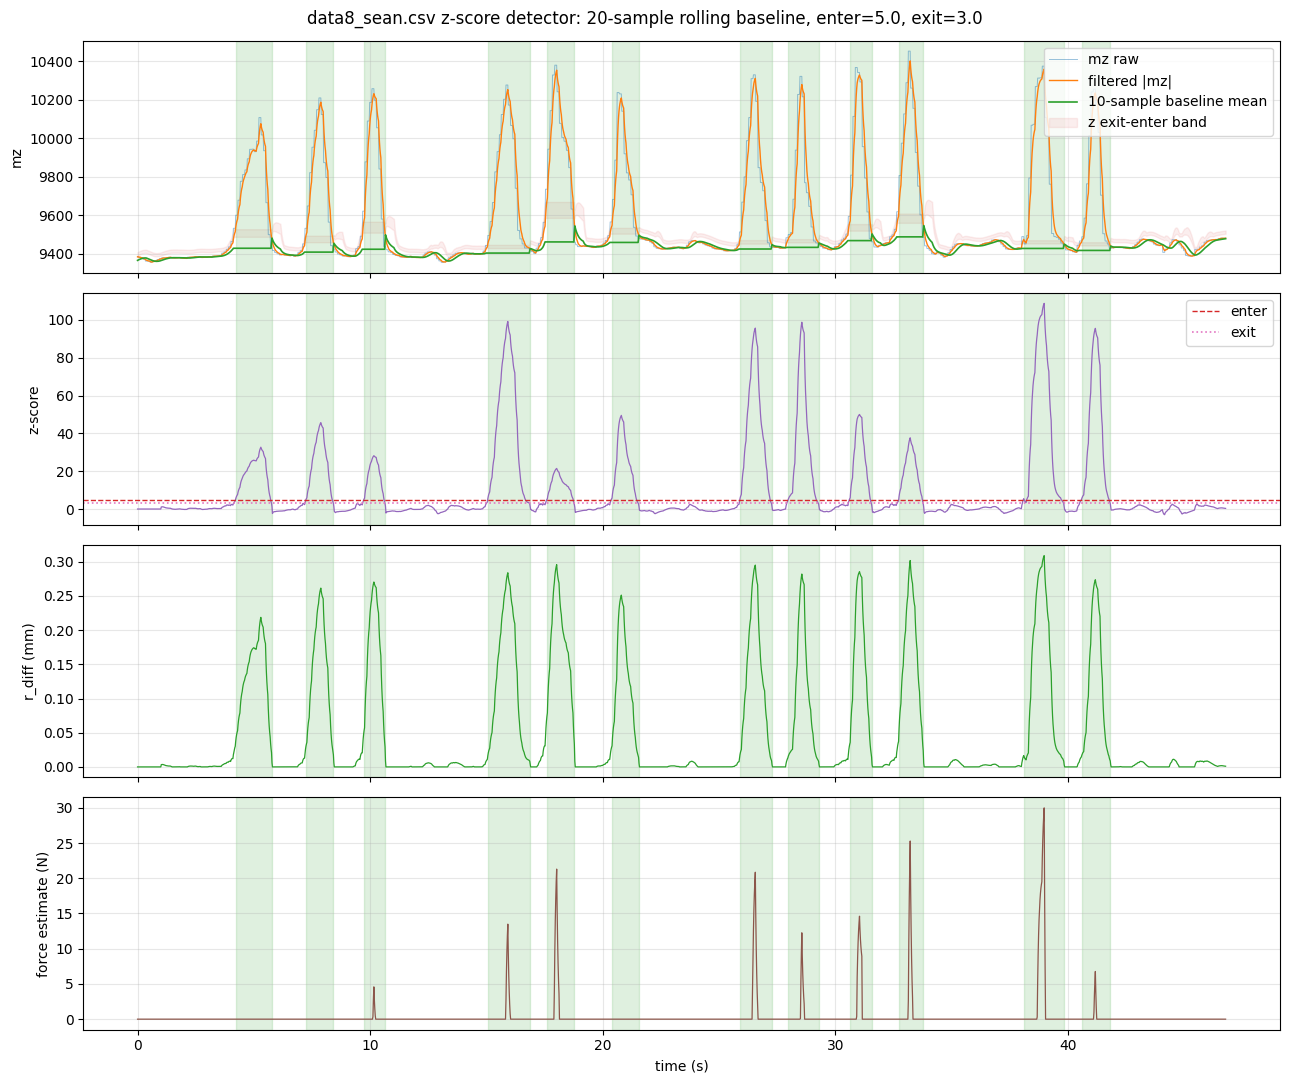

In [3]:
# Z-score detector experiment for data8_sean.csv with same analysis
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("data8_sean.csv")
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 20
Z_ENTER = 5.0
Z_EXIT = 3.0
REFRACTORY_MS = 50.0
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5
BASELINE_DISTANCE_MM = 10.0

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        try:
            rows.append({
                "seq": int(parts[0]),
                "timestamp_ms": float(parts[1]),
                "mz": float(parts[4]),
            })
        except ValueError:
            continue

df = pd.DataFrame(rows)
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
df["abs_mz"] = df["mz"].abs()
df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

startup = df[df["time_s"] <= STARTUP_ZERO_S]
startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)


def window_stats(window):
    vals = pd.Series(list(window), dtype="float64")
    mean = vals.mean()
    std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
    # Keep the rolling mean responsive, but do not let z-score noise scale collapse.
    return mean, max(std, startup_std_floor)


def update_rolling_baseline(window, b):
    window.append(b)
    return window_stats(window)


baseline_mean, baseline_std = window_stats(baseline_window)
startup_mean = baseline_mean
startup_std = baseline_std

state = "idle"
load_start_t = None
last_release_t = -1e9
events = []

states = []
baseline_means = []
baseline_stds = []
z_scores = []
r_diffs = []
forces = []

for row in df.itertuples(index=False):
    t = row.time_s
    b = row.abs_mz_lpf

    # During startup, keep filling the same 10-sample rolling window.
    if t <= STARTUP_ZERO_S:
        baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        z = 0.0
        r_diff = 0.0
        force_n = 0.0
        states.append("zeroing")
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)
        r_diffs.append(r_diff)
        forces.append(force_n)
        continue

    z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

    r_diff = 0.0
    if b > 1.0 and baseline_mean > 1.0 and b > baseline_mean:
        r_mm = BASELINE_DISTANCE_MM * (baseline_mean / b) ** (1.0 / 3.0)
        r_diff = BASELINE_DISTANCE_MM - r_mm
    force_n = max(FORCE_SLOPE * r_diff + FORCE_INTERCEPT, 0.0) if r_diff > 0 else 0.0

    if state == "idle":
        can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
        if can_start and z >= Z_ENTER:
            state = "loaded"
            load_start_t = t
        elif abs(z) < Z_EXIT:
            # Only quiet unloaded samples are allowed to teach the baseline.
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        else:
            # Suspicious movement: freeze baseline so the rising edge cannot be learned away.
            pass

    elif state == "loaded":
        if z <= Z_EXIT:
            duration_s = t - load_start_t
            kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
            events.append({
                "start_s": load_start_t,
                "end_s": t,
                "duration_s": duration_s,
                "kind": kind,
            })

            old_mean = baseline_mean
            baseline_window.clear()
            baseline_window.append(b)
            new_window_mean, new_window_std = window_stats(baseline_window)
            baseline_mean = 0.5 * (old_mean + new_window_mean)
            baseline_std = max(0.5 * (baseline_std + new_window_std), STD_FLOOR)

            state = "idle"
            last_release_t = t
            load_start_t = None

    states.append(state)
    baseline_means.append(baseline_mean)
    baseline_stds.append(baseline_std)
    z_scores.append(z)
    r_diffs.append(r_diff)
    forces.append(force_n)

df["state"] = states
df["baseline_mean"] = baseline_means
df["baseline_std"] = baseline_stds
df["z_score"] = z_scores
df["r_diff_mm"] = r_diffs
df["force_n"] = forces

events_df = pd.DataFrame(events)
display(events_df)
print(
    f"startup mean={startup_mean:.2f}, startup std={startup_std:.2f}, "
    f"events={len(events_df)}, steps={(events_df['kind'] == 'step').sum() if len(events_df) else 0}, "
    f"sustained={(events_df['kind'] == 'sustained').sum() if len(events_df) else 0}"
)

fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

axs[0].plot(df["time_s"], df["mz"], lw=0.7, alpha=0.45, label="mz raw")
axs[0].plot(df["time_s"], df["abs_mz_lpf"], lw=1.0, label="filtered |mz|")
axs[0].plot(df["time_s"], df["baseline_mean"], lw=1.2, label="10-sample baseline mean")
axs[0].fill_between(
    df["time_s"],
    df["baseline_mean"] + Z_EXIT * df["baseline_std"],
    df["baseline_mean"] + Z_ENTER * df["baseline_std"],
    color="C3",
    alpha=0.08,
    label="z exit-enter band",
)
axs[0].set_ylabel("mz")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df["time_s"], df["z_score"], lw=0.9, color="C4")
axs[1].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="enter")
axs[1].axhline(Z_EXIT, color="C6", ls=":", lw=1.2, label="exit")
axs[1].set_ylabel("z-score")
axs[1].legend(loc="upper right")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df["time_s"], df["r_diff_mm"], lw=0.9, color="C2")
axs[2].set_ylabel("r_diff (mm)")
axs[2].grid(True, alpha=0.3)

axs[3].plot(df["time_s"], df["force_n"], lw=0.9, color="C5")
axs[3].set_ylabel("force estimate (N)")
axs[3].set_xlabel("time (s)")
axs[3].grid(True, alpha=0.3)

for event in events:
    color = "C2" if event["kind"] == "step" else "C1"
    for ax in axs:
        ax.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

fig.suptitle(f"data8_sean.csv z-score detector: {BASELINE_WINDOW_SAMPLES}-sample rolling baseline, enter={Z_ENTER}, exit={Z_EXIT}")
plt.tight_layout()
plt.show()


,file,events,steps,sustained,max_z
0,data_normal.csv,6,6,0,17.3
1,data2_start_stop.csv,8,6,2,15.6
2,data3_3stepsthenfall.csv,2,2,0,8.6
3,data4obstacles.csv,1,1,0,9.5
4,data5.csv,2,2,0,11.8
5,data6.csv,1,1,0,5.9
6,data7_sean.csv,7,7,0,71.3
7,data8_sean.csv,12,12,0,108.8
8,data9_sean_2_stops.csv,11,7,4,155.7


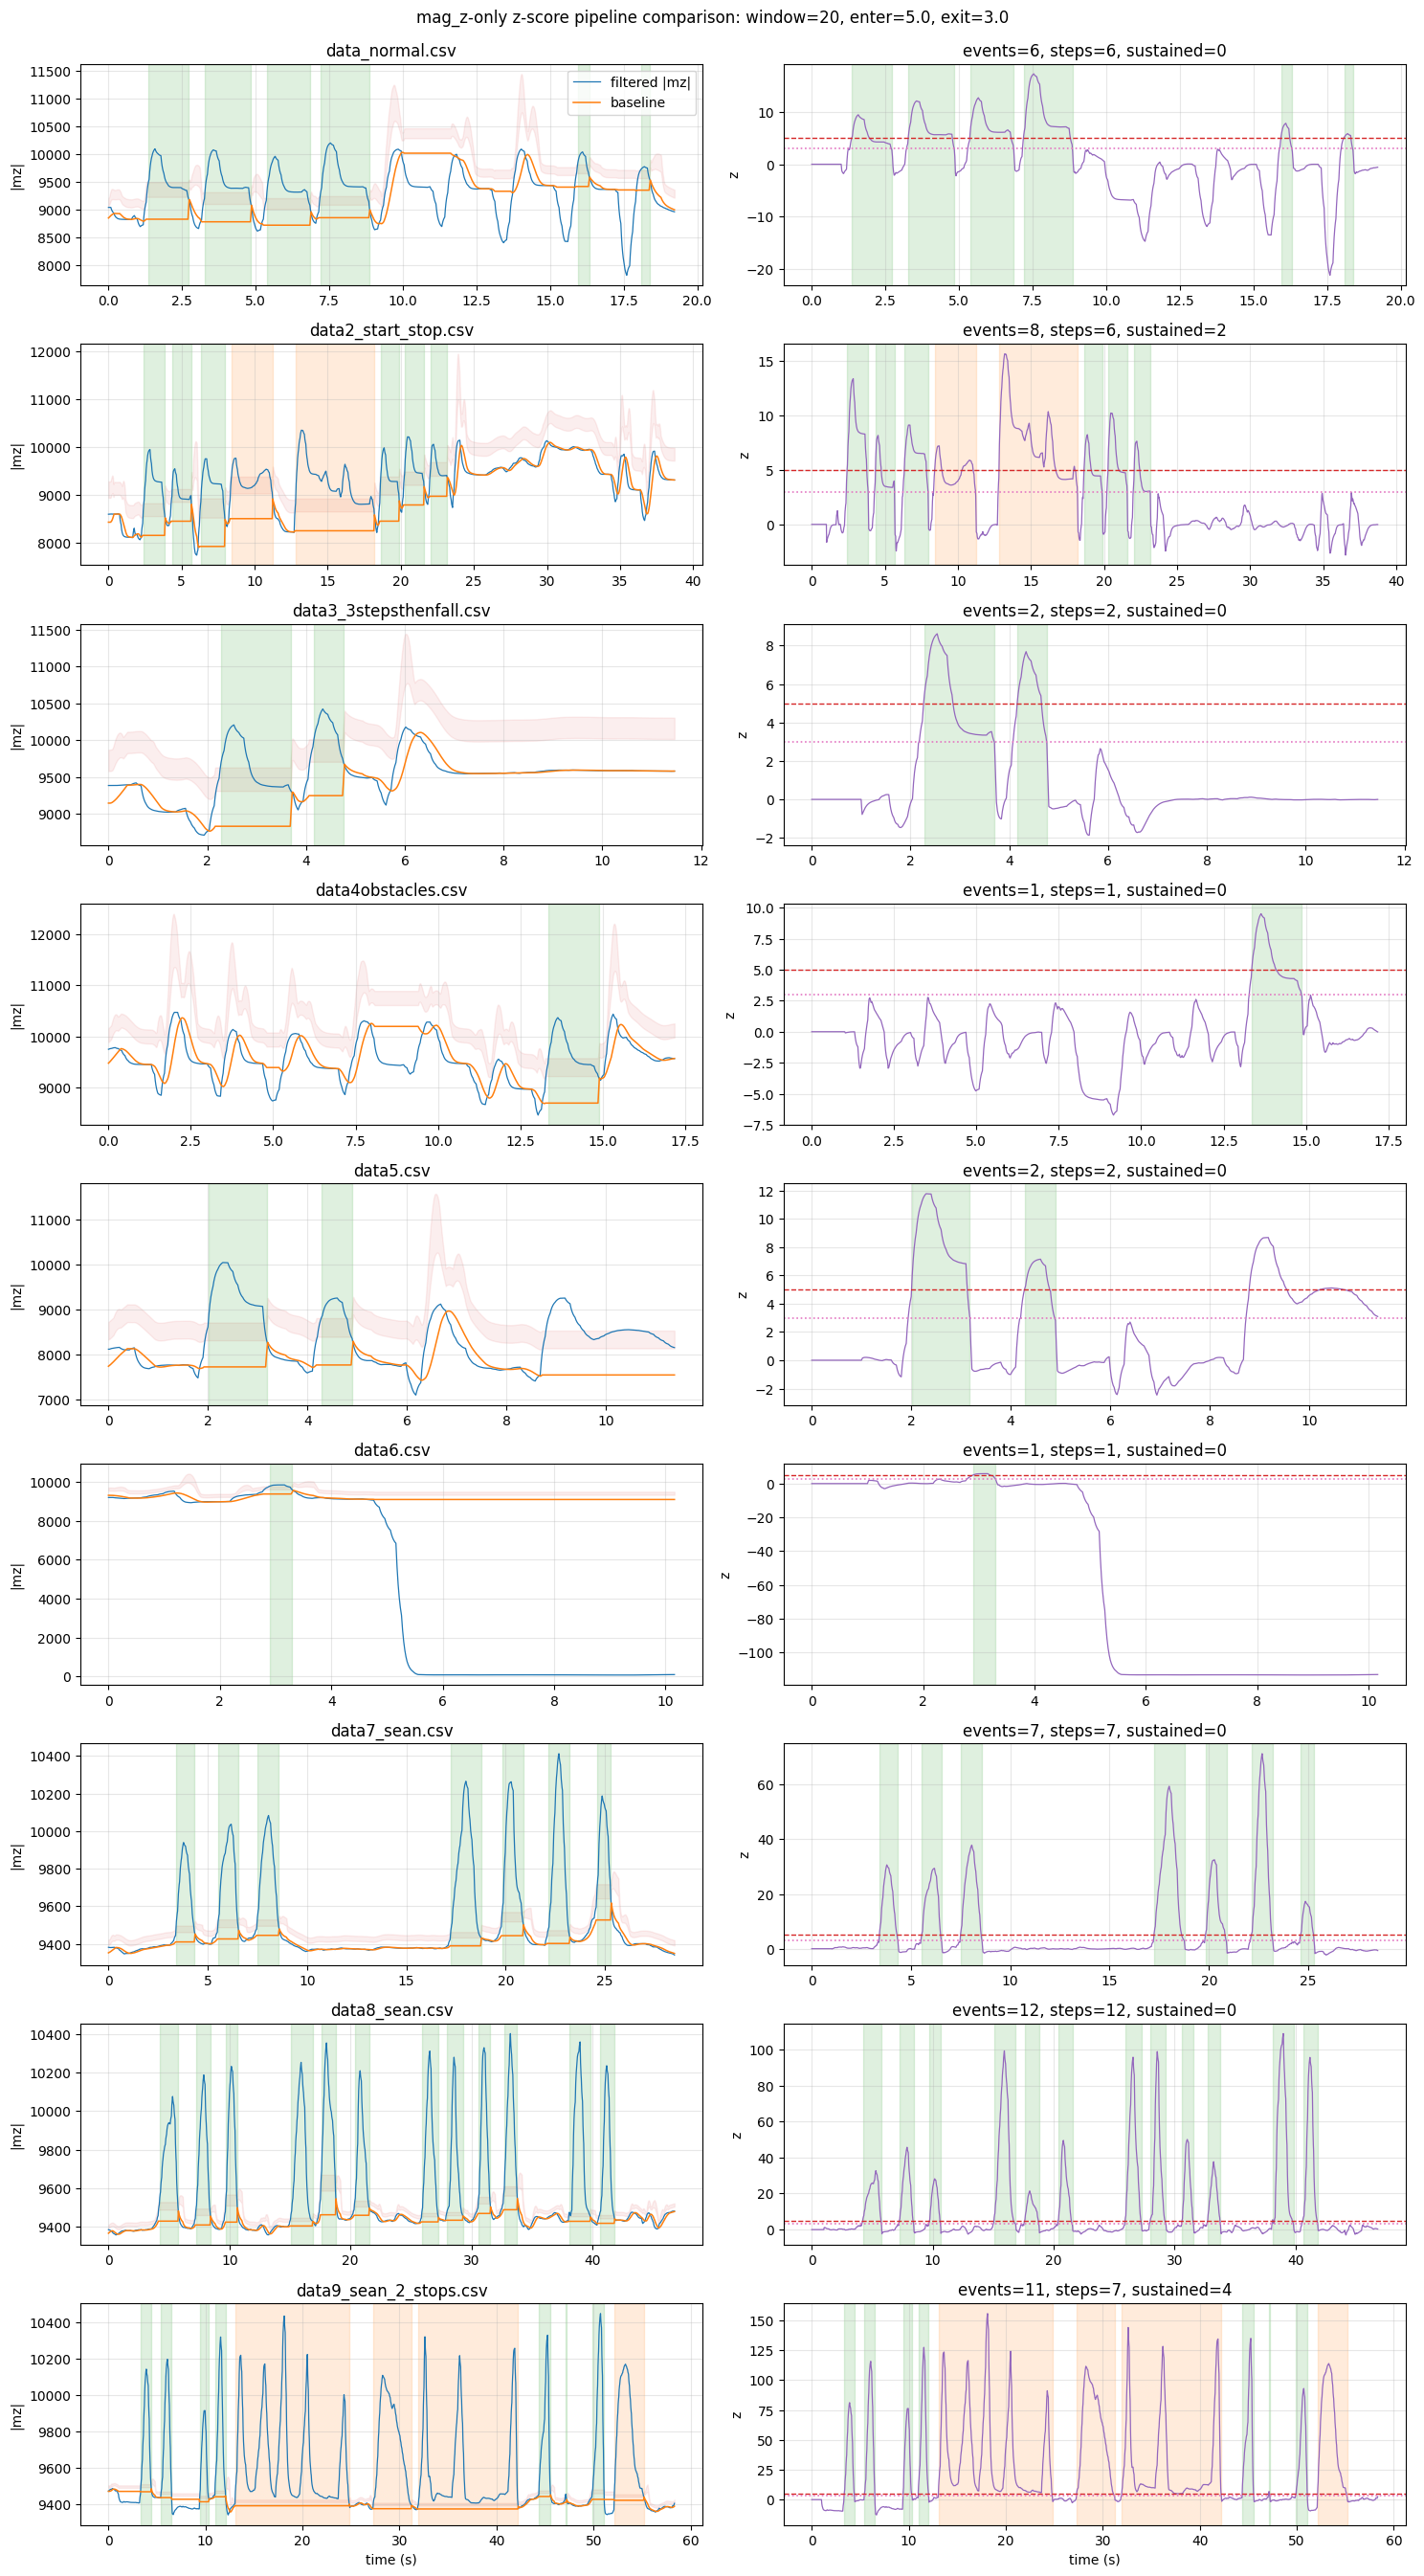

In [195]:
# Compare the current mag_z-only z-score pipeline across recordings
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_FILES_COMPARE = [
    "data_normal.csv",
    "data2_start_stop.csv",
    "data3_3stepsthenfall.csv",
    "data4obstacles.csv",
    "data5.csv",
    "data6.csv",
    "data7_sean.csv",
    "data8_sean.csv",
    "data9_sean_2_stops.csv",
]

STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 20
Z_ENTER = 5.0
Z_EXIT = 3.0
REFRACTORY_MS = 10
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0


def load_mz_csv(path):
    rows = []
    with Path(path).open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(",")
            if len(parts) < 5:
                continue
            try:
                rows.append({
                    "seq": int(parts[0]),
                    "timestamp_ms": float(parts[1]),
                    "mz": float(parts[4]),
                })
            except ValueError:
                continue
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["abs_mz"] = df["mz"].abs()
    df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()
    return df


def run_z_pipeline(df):
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
    baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
        return mean, max(std, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    last_release_t = -1e9
    events = []

    states = []
    baseline_means = []
    baseline_stds = []
    z_scores = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.abs_mz_lpf

        if t <= STARTUP_ZERO_S:
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing")
            baseline_means.append(baseline_mean)
            baseline_stds.append(baseline_std)
            z_scores.append(0.0)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            if can_start and z >= Z_ENTER:
                state = "loaded"
                load_start_t = t
            elif abs(z) < Z_EXIT:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)

        elif state == "loaded":
            if z <= Z_EXIT:
                duration_s = t - load_start_t
                kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
                events.append({
                    "start_s": load_start_t,
                    "end_s": t,
                    "duration_s": duration_s,
                    "kind": kind,
                })

                old_mean = baseline_mean
                old_std = baseline_std
                baseline_window.clear()
                baseline_window.append(b)
                new_window_mean, new_window_std = window_stats(baseline_window)
                baseline_mean = 0.5 * (old_mean + new_window_mean)
                baseline_std = max(0.5 * (old_std + new_window_std), STD_FLOOR)

                state = "idle"
                last_release_t = t
                load_start_t = None

        states.append(state)
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)

    out = df.copy()
    out["state"] = states
    out["baseline_mean"] = baseline_means
    out["baseline_std"] = baseline_stds
    out["z_score"] = z_scores
    return out, pd.DataFrame(events)


results = []
valid = []
for name in CSV_FILES_COMPARE:
    path = Path(name)
    if not path.exists():
        continue
    df_raw = load_mz_csv(path)
    if df_raw.empty:
        continue
    df_z, events_df = run_z_pipeline(df_raw)
    valid.append((name, df_z, events_df))
    results.append({
        "file": name,
        "events": len(events_df),
        "steps": int((events_df["kind"] == "step").sum()) if len(events_df) else 0,
        "sustained": int((events_df["kind"] == "sustained").sum()) if len(events_df) else 0,
        "max_z": round(float(df_z["z_score"].max()), 1),
    })

display(pd.DataFrame(results))

fig, axes = plt.subplots(len(valid), 2, figsize=(15, 3.0 * len(valid)), sharex=False)
if len(valid) == 1:
    axes = [axes]

for (name, df_z, events_df), (ax_mz, ax_z) in zip(valid, axes):
    ax_mz.plot(df_z["time_s"], df_z["abs_mz_lpf"], lw=0.9, label="filtered |mz|")
    ax_mz.plot(df_z["time_s"], df_z["baseline_mean"], lw=1.1, label="baseline")
    ax_mz.fill_between(
        df_z["time_s"],
        df_z["baseline_mean"] + Z_EXIT * df_z["baseline_std"],
        df_z["baseline_mean"] + Z_ENTER * df_z["baseline_std"],
        color="C3",
        alpha=0.08,
    )
    ax_mz.set_title(name)
    ax_mz.set_ylabel("|mz|")
    ax_mz.grid(True, alpha=0.3)

    ax_z.plot(df_z["time_s"], df_z["z_score"], lw=0.9, color="C4")
    ax_z.axhline(Z_ENTER, color="C3", ls="--", lw=1.0)
    ax_z.axhline(Z_EXIT, color="C6", ls=":", lw=1.2)
    ax_z.set_ylabel("z")
    ax_z.grid(True, alpha=0.3)

    for event in events_df.to_dict("records"):
        color = "C2" if event["kind"] == "step" else "C1"
        ax_mz.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)
        ax_z.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

    ax_z.set_title(
        f"events={len(events_df)}, steps={int((events_df['kind'] == 'step').sum()) if len(events_df) else 0}, "
        f"sustained={int((events_df['kind'] == 'sustained').sum()) if len(events_df) else 0}"
    )

axes[-1][0].set_xlabel("time (s)")
axes[-1][1].set_xlabel("time (s)")
axes[0][0].legend(loc="upper right")
fig.suptitle(
    f"mag_z-only z-score pipeline comparison: window={BASELINE_WINDOW_SAMPLES}, enter={Z_ENTER}, exit={Z_EXIT}",
    y=0.995,
)
plt.tight_layout()
plt.show()


,start_s,end_s,duration_s,kind
0,3.36,4.40,1.04,step
1,5.44,6.52,1.08,step
2,9.42,10.34,0.92,step
3,10.98,12.06,1.08,step
4,13.06,24.80,11.74,sustained
5,27.32,31.22,3.90,sustained
6,31.96,42.22,10.26,sustained
7,44.38,45.56,1.18,step
8,47.10,47.22,0.12,step
9,49.92,51.10,1.18,step


startup mean=9472.87, startup std=6.55, events=11, steps=7, sustained=4


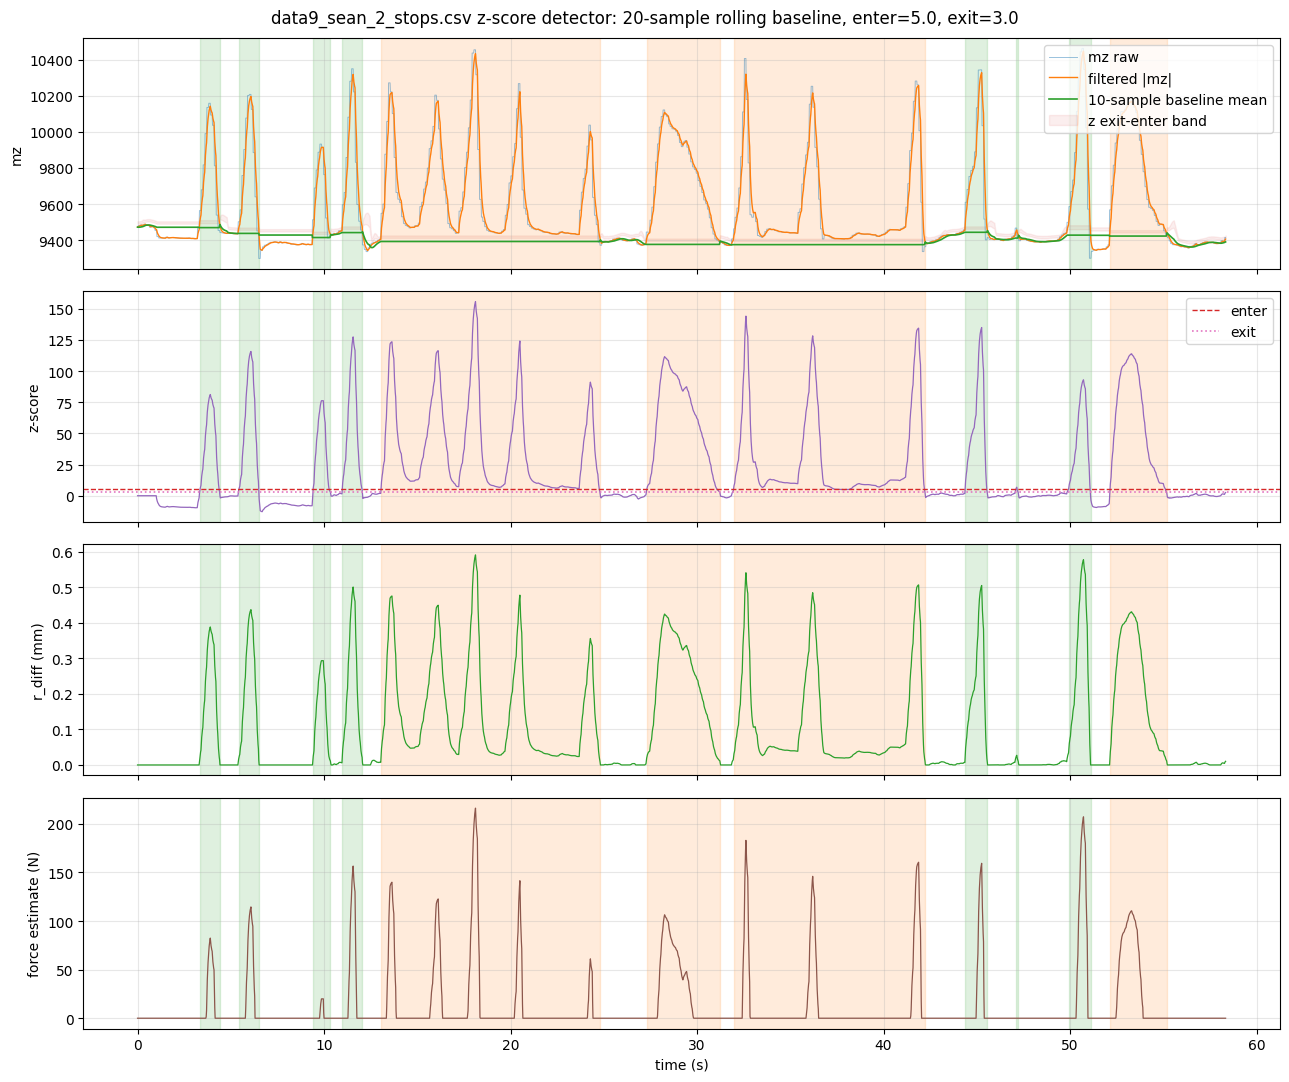

In [4]:
# Z-score detector experiment for data9_sean_2_stops.csv with same analysis
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("data9_sean_2_stops.csv")
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 20
Z_ENTER = 5.0
Z_EXIT = 3.0
REFRACTORY_MS = 50.0
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5
BASELINE_DISTANCE_MM = 17.2

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        try:
            rows.append({
                "seq": int(parts[0]),
                "timestamp_ms": float(parts[1]),
                "mz": float(parts[4]),
            })
        except ValueError:
            continue

df = pd.DataFrame(rows)
df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
df["abs_mz"] = df["mz"].abs()
df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

startup = df[df["time_s"] <= STARTUP_ZERO_S]
startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)


def window_stats(window):
    vals = pd.Series(list(window), dtype="float64")
    mean = vals.mean()
    std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
    # Keep the rolling mean responsive, but do not let z-score noise scale collapse.
    return mean, max(std, startup_std_floor)


def update_rolling_baseline(window, b):
    window.append(b)
    return window_stats(window)


baseline_mean, baseline_std = window_stats(baseline_window)
startup_mean = baseline_mean
startup_std = baseline_std

state = "idle"
load_start_t = None
last_release_t = -1e9
events = []

states = []
baseline_means = []
baseline_stds = []
z_scores = []
r_diffs = []
forces = []

for row in df.itertuples(index=False):
    t = row.time_s
    b = row.abs_mz_lpf

    # During startup, keep filling the same 10-sample rolling window.
    if t <= STARTUP_ZERO_S:
        baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        z = 0.0
        r_diff = 0.0
        force_n = 0.0
        states.append("zeroing")
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)
        r_diffs.append(r_diff)
        forces.append(force_n)
        continue

    z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

    r_diff = 0.0
    if b > 1.0 and baseline_mean > 1.0 and b > baseline_mean:
        r_mm = BASELINE_DISTANCE_MM * (baseline_mean / b) ** (1.0 / 3.0)
        r_diff = BASELINE_DISTANCE_MM - r_mm
    force_n = max(FORCE_SLOPE * r_diff + FORCE_INTERCEPT, 0.0) if r_diff > 0 else 0.0

    if state == "idle":
        can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
        if can_start and z >= Z_ENTER:
            state = "loaded"
            load_start_t = t
        elif abs(z) < Z_EXIT:
            # Only quiet unloaded samples are allowed to teach the baseline.
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
        else:
            # Suspicious movement: freeze baseline so the rising edge cannot be learned away.
            pass

    elif state == "loaded":
        if z <= Z_EXIT:
            duration_s = t - load_start_t
            kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
            events.append({
                "start_s": load_start_t,
                "end_s": t,
                "duration_s": duration_s,
                "kind": kind,
            })

            old_mean = baseline_mean
            baseline_window.clear()
            baseline_window.append(b)
            new_window_mean, new_window_std = window_stats(baseline_window)
            baseline_mean = 0.5 * (old_mean + new_window_mean)
            baseline_std = max(0.5 * (baseline_std + new_window_std), STD_FLOOR)

            state = "idle"
            last_release_t = t
            load_start_t = None

    states.append(state)
    baseline_means.append(baseline_mean)
    baseline_stds.append(baseline_std)
    z_scores.append(z)
    r_diffs.append(r_diff)
    forces.append(force_n)

df["state"] = states
df["baseline_mean"] = baseline_means
df["baseline_std"] = baseline_stds
df["z_score"] = z_scores
df["r_diff_mm"] = r_diffs
df["force_n"] = forces

events_df = pd.DataFrame(events)
display(events_df)
print(
    f"startup mean={startup_mean:.2f}, startup std={startup_std:.2f}, "
    f"events={len(events_df)}, steps={(events_df['kind'] == 'step').sum() if len(events_df) else 0}, "
    f"sustained={(events_df['kind'] == 'sustained').sum() if len(events_df) else 0}"
)

fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

axs[0].plot(df["time_s"], df["mz"], lw=0.7, alpha=0.45, label="mz raw")
axs[0].plot(df["time_s"], df["abs_mz_lpf"], lw=1.0, label="filtered |mz|")
axs[0].plot(df["time_s"], df["baseline_mean"], lw=1.2, label="10-sample baseline mean")
axs[0].fill_between(
    df["time_s"],
    df["baseline_mean"] + Z_EXIT * df["baseline_std"],
    df["baseline_mean"] + Z_ENTER * df["baseline_std"],
    color="C3",
    alpha=0.08,
    label="z exit-enter band",
)
axs[0].set_ylabel("mz")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df["time_s"], df["z_score"], lw=0.9, color="C4")
axs[1].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="enter")
axs[1].axhline(Z_EXIT, color="C6", ls=":", lw=1.2, label="exit")
axs[1].set_ylabel("z-score")
axs[1].legend(loc="upper right")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df["time_s"], df["r_diff_mm"], lw=0.9, color="C2")
axs[2].set_ylabel("r_diff (mm)")
axs[2].grid(True, alpha=0.3)

axs[3].plot(df["time_s"], df["force_n"], lw=0.9, color="C5")
axs[3].set_ylabel("force estimate (N)")
axs[3].set_xlabel("time (s)")
axs[3].grid(True, alpha=0.3)

for event in events:
    color = "C2" if event["kind"] == "step" else "C1"
    for ax in axs:
        ax.axvspan(event["start_s"], event["end_s"], color=color, alpha=0.15)

fig.suptitle(f"data9_sean_2_stops.csv z-score detector: {BASELINE_WINDOW_SAMPLES}-sample rolling baseline, enter={Z_ENTER}, exit={Z_EXIT}")
plt.tight_layout()
plt.show()


In [197]:
# Plot acceleration channels for raw-capture CSVs
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ACCEL_CSV = Path("data9_sean_2_stops.csv")  # change this to your raw-capture file


def load_raw_capture_csv(path):
    rows = []
    header = None
    with Path(path).open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                continue
            parts = line.split(",")
            if parts[0] == "seq":
                header = parts
                continue
            try:
                vals = [float(p) for p in parts]
            except ValueError:
                continue
            rows.append(vals)

    if not rows:
        return pd.DataFrame()

    width = max(len(r) for r in rows)
    rows = [r + [np.nan] * (width - len(r)) for r in rows]

    if header and len(header) == width:
        cols = header
    elif width >= 14:
        cols = [
            "seq", "timestamp_ms",
            "ax", "ay", "az",
            "gx", "gy", "gz",
            "roll", "pitch", "yaw",
            "mx", "my", "mz",
        ] + [f"extra_{i}" for i in range(width - 14)]
    elif width >= 5:
        cols = ["seq", "timestamp_ms", "mx", "my", "mz"] + [f"extra_{i}" for i in range(width - 5)]
    else:
        cols = [f"col_{i}" for i in range(width)]

    df = pd.DataFrame(rows, columns=cols)
    time_col = "timestamp_ms" if "timestamp_ms" in df.columns else df.columns[1]
    df["time_s"] = (df[time_col] - df[time_col].iloc[0]) / 1000.0
    return df


df_acc = load_raw_capture_csv(ACCEL_CSV)
if df_acc.empty:
    print(f"No parseable rows in {ACCEL_CSV}")
elif not {"ax", "ay", "az"}.issubset(df_acc.columns):
    print(
        f"{ACCEL_CSV} does not include accel columns. "
        "It looks like a magnetometer-only capture. "
        "Use a CSV from the new raw firmware format to plot acceleration."
    )
    display(df_acc.head())
else:
    df_acc["acc_mag"] = np.sqrt(df_acc["ax"]**2 + df_acc["ay"]**2 + df_acc["az"]**2)

    fig, axs = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

    axs[0].plot(df_acc["time_s"], df_acc["ax"], lw=0.9, label="ax")
    axs[0].plot(df_acc["time_s"], df_acc["ay"], lw=0.9, label="ay")
    axs[0].plot(df_acc["time_s"], df_acc["az"], lw=0.9, label="az")
    axs[0].set_ylabel("accel (g)")
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(df_acc["time_s"], df_acc["acc_mag"], lw=0.9, color="C4", label="|a|")
    axs[1].axhline(1.0, color="k", lw=0.8, alpha=0.5, label="1 g")
    axs[1].set_ylabel("|accel| (g)")
    axs[1].legend(loc="upper right")
    axs[1].grid(True, alpha=0.3)

    if {"mx", "my", "mz"}.issubset(df_acc.columns):
        axs[2].plot(df_acc["time_s"], df_acc["mz"], lw=0.9, color="C2", label="mz")
        axs[2].set_ylabel("mz raw")
        axs[2].legend(loc="upper right")
    else:
        axs[2].text(0.5, 0.5, "No magnetometer columns", ha="center", va="center", transform=axs[2].transAxes)
    axs[2].set_xlabel("time (s)")
    axs[2].grid(True, alpha=0.3)

    fig.suptitle(f"Acceleration channels: {ACCEL_CSV}")
    plt.tight_layout()
    plt.show()


data9_sean_2_stops.csv does not include accel columns. It looks like a magnetometer-only capture. Use a CSV from the new raw firmware format to plot acceleration.


,seq,timestamp_ms,mx,my,mz,time_s
0,0.0,54288.0,2306.0,-258.0,9472.0,0.00
1,1.0,54308.0,2306.0,-258.0,9472.0,0.02
2,2.0,54328.0,2310.0,-255.0,9481.0,0.04
3,3.0,54348.0,2310.0,-255.0,9481.0,0.06
4,4.0,54368.0,2310.0,-255.0,9481.0,0.08


,file,candidates,accepted,rejected,steps,sustained,max_z
0,data7_sean.csv,7,7,0,7,0,72.4
1,data8_sean.csv,12,12,0,12,0,103.8
2,data9_sean_2_stops.csv,16,15,1,12,3,160.1


,file,start_s,release_s,duration_s,kind,accepted,reject_reason,peak_amp,area
0,data7_sean.csv,3.40,4.36,0.96,step,True,,544.401442,327.016525
1,data7_sean.csv,5.50,6.56,1.06,step,True,,626.817568,431.943260
2,data7_sean.csv,7.50,8.58,1.08,step,True,,648.519936,445.857405
3,data7_sean.csv,17.24,18.62,1.38,step,True,,884.162094,686.431562
4,data7_sean.csv,19.80,20.90,1.10,step,True,,838.996059,503.290197
5,data7_sean.csv,22.14,23.14,1.00,step,True,,1010.535050,569.626302
6,data7_sean.csv,24.30,25.46,1.16,step,True,,761.754125,454.653435
7,data8_sean.csv,4.02,5.82,1.80,step,True,,685.503513,701.743930
8,data8_sean.csv,7.16,8.40,1.24,step,True,,791.358673,540.013993
9,data8_sean.csv,9.62,10.68,1.06,step,True,,832.899580,519.607169


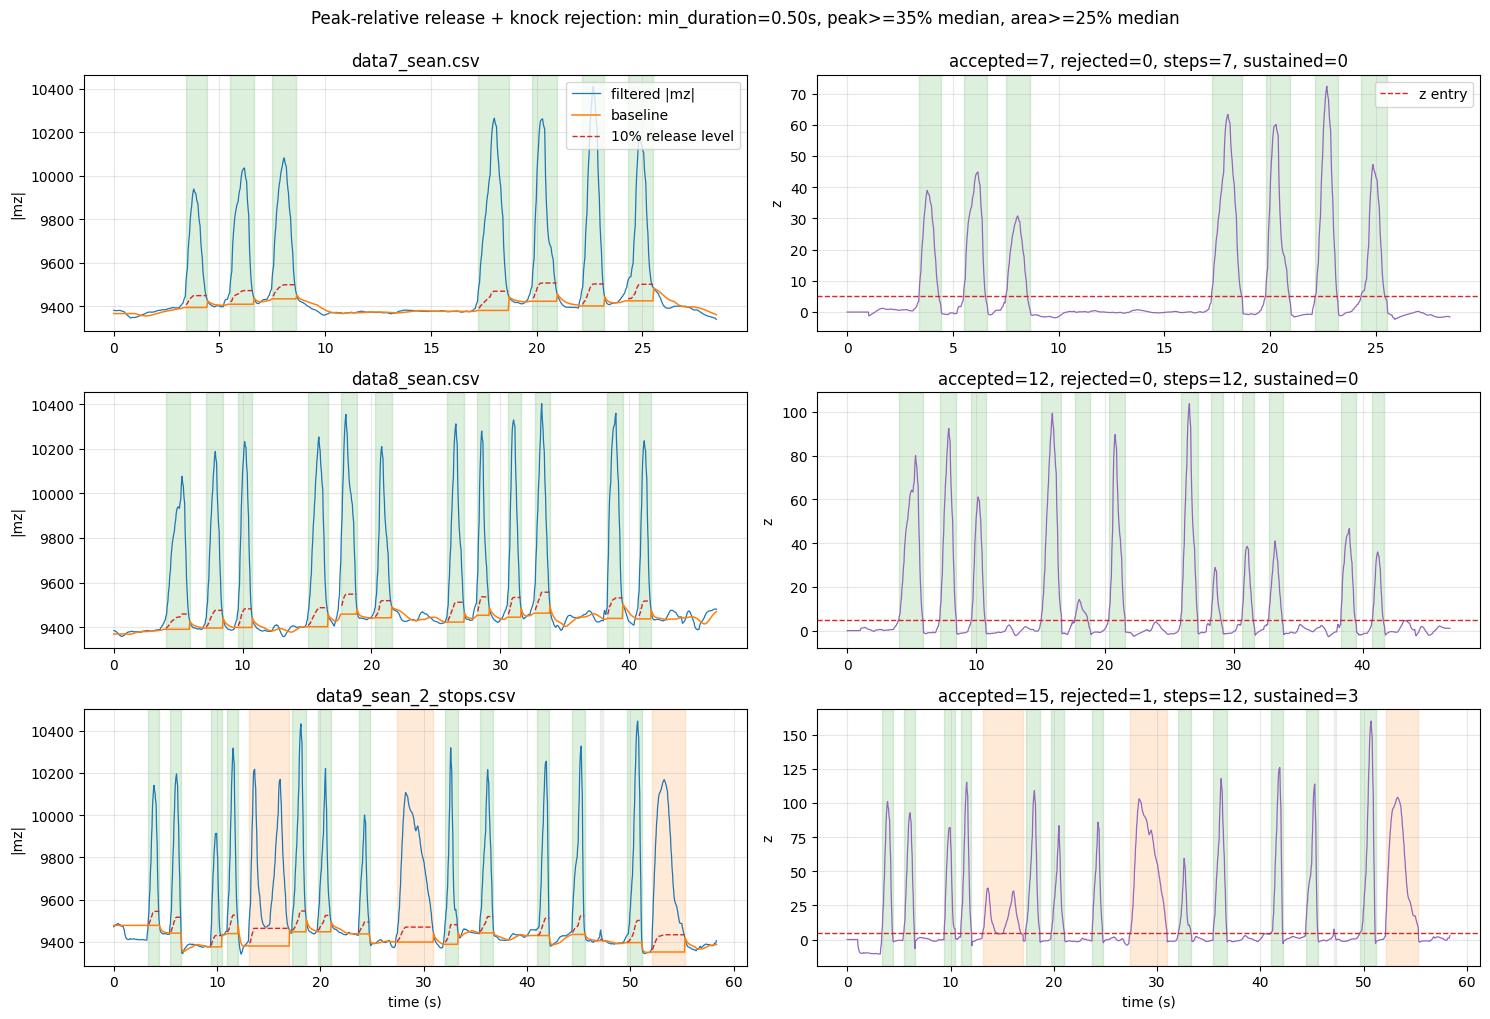

In [5]:
# Peak-relative release experiment: z-score entry, 5% peak-to-baseline exit + knock rejection
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV_FILES_PEAK_RELEASE = [
    "data7_sean.csv",
    "data8_sean.csv",
    "data9_sean_2_stops.csv",
]

STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 50
Z_ENTER = 5.0
Z_EXIT_FOR_BASELINE_UPDATE = 3.0
RELEASE_FRACTION = 0.1
RELEASE_CONFIRM_MS = 50.0
REFRACTORY_MS = 50.0
POST_RELEASE_BASELINE_SAMPLES = BASELINE_WINDOW_SAMPLES
SUSTAINED_CUTOFF_S = 2.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
MIN_DURATION_S = 0.50
MIN_PEAK_FRAC_OF_MEDIAN = 0.35
MIN_AREA_FRAC_OF_MEDIAN = 0.25


def load_mz_csv(path):
    rows = []
    with Path(path).open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(",")
            if len(parts) < 5:
                continue
            try:
                rows.append({
                    "seq": int(parts[0]),
                    "timestamp_ms": float(parts[1]),
                    "mz": float(parts[4]),
                })
            except ValueError:
                continue

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["abs_mz"] = df["mz"].abs()
    df["abs_mz_lpf"] = df["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()
    return df


def event_area(df, start_s, release_s, baseline):
    event_df = df[(df["time_s"] >= start_s) & (df["time_s"] <= release_s)]
    if len(event_df) < 2:
        return 0.0
    y = (event_df["abs_mz_lpf"] - baseline).clip(lower=0.0)
    return float(np.trapz(y, event_df["time_s"]))


def classify_rejections(events_df):
    if events_df.empty:
        events_df["accepted"] = []
        events_df["reject_reason"] = []
        return events_df

    median_peak_amp = events_df["peak_amp"].median()
    median_area = events_df["area"].median()

    accepted = []
    reasons = []
    for row in events_df.itertuples(index=False):
        reason_parts = []
        if row.duration_s < MIN_DURATION_S:
            reason_parts.append("short")
        if median_peak_amp > 0 and row.peak_amp < MIN_PEAK_FRAC_OF_MEDIAN * median_peak_amp:
            reason_parts.append("small_peak")
        if median_area > 0 and row.area < MIN_AREA_FRAC_OF_MEDIAN * median_area:
            reason_parts.append("small_area")
        accepted.append(not reason_parts)
        reasons.append(",".join(reason_parts))

    events_df = events_df.copy()
    events_df["accepted"] = accepted
    events_df["reject_reason"] = reasons
    events_df["median_peak_amp"] = median_peak_amp
    events_df["median_area"] = median_area
    return events_df


def run_peak_release_pipeline(df):
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    startup_std_floor = max(startup["abs_mz_lpf"].std(ddof=1), STD_FLOOR)
    baseline_window = deque(startup["abs_mz_lpf"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
        return mean, max(std, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    release_candidate_t = None
    last_release_t = -1e9
    post_release_baseline_samples = 0
    baseline_at_entry = None
    peak_mz = None
    release_level = np.nan
    events = []

    states = []
    baseline_means = []
    baseline_stds = []
    z_scores = []
    release_levels = []
    peak_values = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.abs_mz_lpf

        if t <= STARTUP_ZERO_S:
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing")
            baseline_means.append(baseline_mean)
            baseline_stds.append(baseline_std)
            z_scores.append(0.0)
            release_levels.append(np.nan)
            peak_values.append(np.nan)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            if can_start and z >= Z_ENTER:
                state = "loaded"
                load_start_t = t
                release_candidate_t = None
                baseline_at_entry = baseline_mean
                peak_mz = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_mz - baseline_at_entry)
                post_release_baseline_samples = 0
            elif post_release_baseline_samples > 0:
                # Release starts baseline collection immediately, but does not block a new event
                # after the short refractory period has elapsed.
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
                post_release_baseline_samples -= 1
            elif abs(z) < Z_EXIT_FOR_BASELINE_UPDATE:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            release_levels.append(np.nan)
            peak_values.append(np.nan)

        elif state == "loaded":
            if b > peak_mz:
                peak_mz = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_mz - baseline_at_entry)

            if b <= release_level:
                state = "releasing"
                release_candidate_t = t

            release_levels.append(release_level)
            peak_values.append(peak_mz)

        elif state == "releasing":
            if b > peak_mz:
                peak_mz = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_mz - baseline_at_entry)

            if b > release_level:
                state = "loaded"
                release_candidate_t = None
            elif (t - release_candidate_t) * 1000.0 >= RELEASE_CONFIRM_MS:
                release_t = release_candidate_t
                duration_s = release_t - load_start_t
                kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
                peak_amp = peak_mz - baseline_at_entry
                area = event_area(df, load_start_t, release_t, baseline_at_entry)
                events.append({
                    "start_s": load_start_t,
                    "release_s": release_t,
                    "confirm_s": t,
                    "duration_s": duration_s,
                    "kind": kind,
                    "baseline_at_entry": baseline_at_entry,
                    "peak_mz": peak_mz,
                    "peak_amp": peak_amp,
                    "area": area,
                    "release_level": release_level,
                })

                old_mean = baseline_mean
                old_std = baseline_std
                baseline_window.clear()
                baseline_window.append(b)
                new_window_mean, new_window_std = window_stats(baseline_window)
                baseline_mean = 0.5 * (old_mean + new_window_mean)
                baseline_std = max(0.5 * (old_std + new_window_std), STD_FLOOR)
                post_release_baseline_samples = POST_RELEASE_BASELINE_SAMPLES - 1

                state = "idle"
                load_start_t = None
                release_candidate_t = None
                last_release_t = t
                baseline_at_entry = None
                peak_mz = None
                release_level = np.nan

            release_levels.append(release_level)
            peak_values.append(peak_mz if peak_mz is not None else np.nan)

        states.append(state)
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)

    out = df.copy()
    out["state"] = states
    out["baseline_mean"] = baseline_means
    out["baseline_std"] = baseline_stds
    out["z_score"] = z_scores
    out["release_level"] = release_levels
    out["peak_mz"] = peak_values
    events_df = classify_rejections(pd.DataFrame(events))
    return out, events_df


all_events = []
results = []
series = []
for name in CSV_FILES_PEAK_RELEASE:
    raw_df = load_mz_csv(name)
    if raw_df.empty:
        continue
    detected_df, events_df = run_peak_release_pipeline(raw_df)
    events_df = events_df.copy()
    if len(events_df):
        events_df.insert(0, "file", name)
    all_events.append(events_df)
    series.append((name, detected_df, events_df))
    accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
    rejected_df = events_df[~events_df["accepted"]] if len(events_df) else events_df
    results.append({
        "file": name,
        "candidates": len(events_df),
        "accepted": len(accepted_df),
        "rejected": len(rejected_df),
        "steps": int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0,
        "sustained": int((accepted_df["kind"] == "sustained").sum()) if len(accepted_df) else 0,
        "max_z": round(float(detected_df["z_score"].max()), 1),
    })

summary_df = pd.DataFrame(results)
events_table = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
display(summary_df)
cols = ["file", "start_s", "release_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "area"]
display(events_table[cols] if len(events_table) else events_table)

fig, axes = plt.subplots(len(series), 2, figsize=(15, 3.4 * len(series)), sharex=False)
if len(series) == 1:
    axes = [axes]

for (name, detected_df, events_df), (ax_mz, ax_z) in zip(series, axes):
    ax_mz.plot(detected_df["time_s"], detected_df["abs_mz_lpf"], lw=0.9, label="filtered |mz|")
    ax_mz.plot(detected_df["time_s"], detected_df["baseline_mean"], lw=1.1, label="baseline")
    ax_mz.plot(detected_df["time_s"], detected_df["release_level"], lw=1.0, ls="--", color="C3", label="10% release level")
    ax_mz.set_title(name)
    ax_mz.set_ylabel("|mz|")
    ax_mz.grid(True, alpha=0.3)

    ax_z.plot(detected_df["time_s"], detected_df["z_score"], lw=0.9, color="C4")
    ax_z.axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="z entry")
    ax_z.set_ylabel("z")
    ax_z.grid(True, alpha=0.3)

    for event in events_df.to_dict("records"):
        if not event["accepted"]:
            color = "0.5"
        elif event["kind"] == "step":
            color = "C2"
        else:
            color = "C1"
        alpha = 0.10 if not event["accepted"] else 0.16
        ax_mz.axvspan(event["start_s"], event["confirm_s"], color=color, alpha=alpha)
        ax_z.axvspan(event["start_s"], event["confirm_s"], color=color, alpha=alpha)

    accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
    rejected_df = events_df[~events_df["accepted"]] if len(events_df) else events_df
    steps = int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0
    sustained = int((accepted_df["kind"] == "sustained").sum()) if len(accepted_df) else 0
    ax_z.set_title(f"accepted={len(accepted_df)}, rejected={len(rejected_df)}, steps={steps}, sustained={sustained}")

axes[-1][0].set_xlabel("time (s)")
axes[-1][1].set_xlabel("time (s)")
axes[0][0].legend(loc="upper right")
axes[0][1].legend(loc="upper right")
fig.suptitle(
    f"Peak-relative release + knock rejection: min_duration={MIN_DURATION_S:.2f}s, peak>={MIN_PEAK_FRAC_OF_MEDIAN:.0%} median, area>={MIN_AREA_FRAC_OF_MEDIAN:.0%} median",
    y=0.995,
)
plt.tight_layout()
plt.show()


b0_abs_mz_lpf      9478.296003
R0_MM                25.000000
FORCE_SLOPE         658.700000
FORCE_INTERCEPT    -173.500000
max_r_diff_mm         0.797136
max_force_n         351.573661
mean_force_n         27.794355
Name: data9 force params/summary, dtype: float64

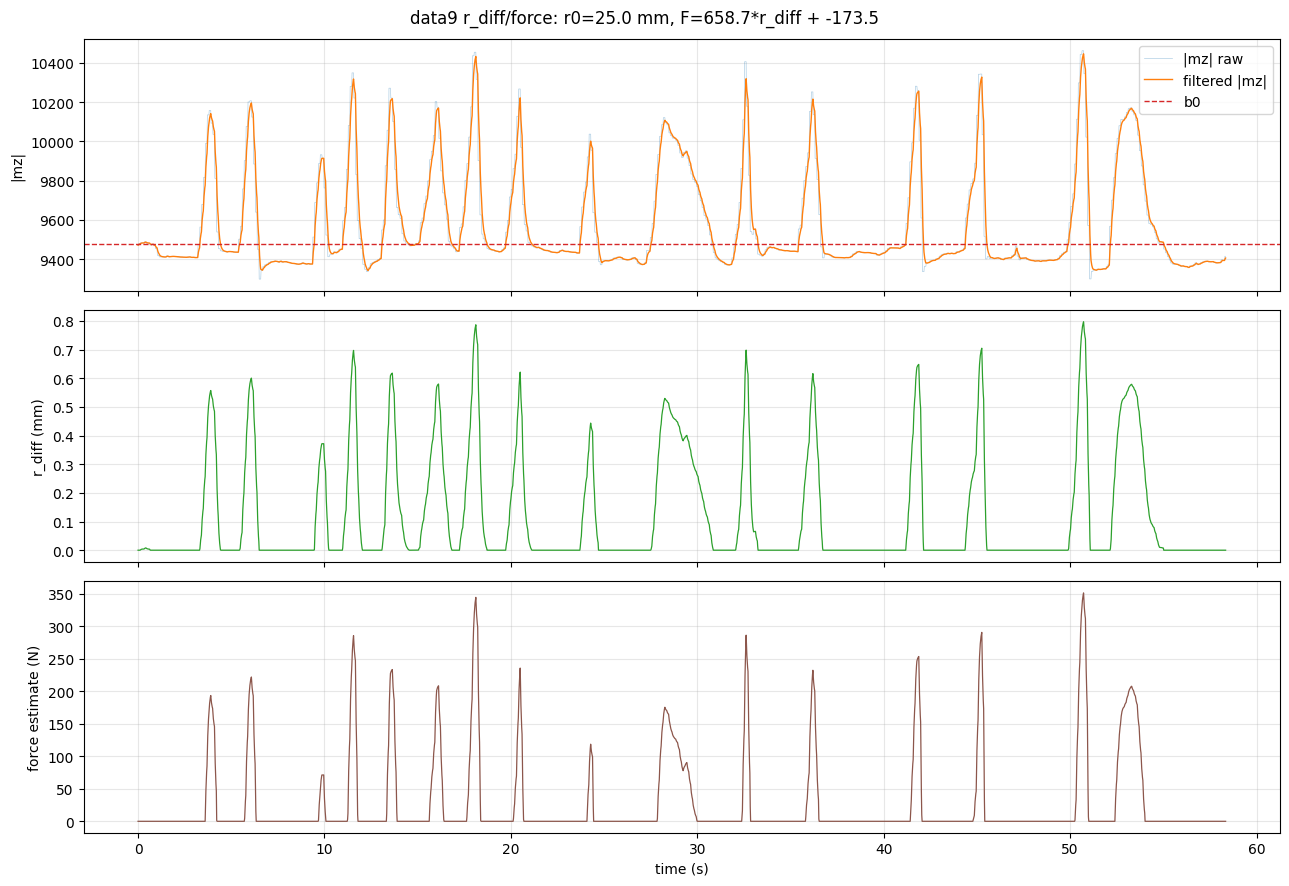

In [7]:
# data9: adjustable r_diff and force estimate from magnetometer
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV_PATH = Path("data9_sean_2_stops.csv")
STARTUP_BASELINE_S = 1.0
MAG_LPF_ALPHA = 0.25

# Tune these three parameters.
R0_MM = 25.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5

rows = []
with CSV_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(",")
        if len(parts) < 5:
            continue
        try:
            rows.append({
                "seq": int(parts[0]),
                "timestamp_ms": float(parts[1]),
                "mx": float(parts[2]),
                "my": float(parts[3]),
                "mz": float(parts[4]),
            })
        except ValueError:
            continue

df_force = pd.DataFrame(rows)
df_force["time_s"] = (df_force["timestamp_ms"] - df_force["timestamp_ms"].iloc[0]) / 1000.0
df_force["abs_mz"] = df_force["mz"].abs()
df_force["abs_mz_lpf"] = df_force["abs_mz"].ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

startup = df_force[df_force["time_s"] <= STARTUP_BASELINE_S]
b0 = startup["abs_mz_lpf"].mean()

ratio = b0 / df_force["abs_mz_lpf"]
ratio = ratio.where((ratio > 0) & np.isfinite(ratio), np.nan)
df_force["r_mm"] = R0_MM * np.cbrt(ratio)
df_force["r_diff_mm"] = (R0_MM - df_force["r_mm"]).clip(lower=0.0)
df_force["force_n"] = (FORCE_SLOPE * df_force["r_diff_mm"] + FORCE_INTERCEPT).clip(lower=0.0)

display(pd.Series({
    "b0_abs_mz_lpf": b0,
    "R0_MM": R0_MM,
    "FORCE_SLOPE": FORCE_SLOPE,
    "FORCE_INTERCEPT": FORCE_INTERCEPT,
    "max_r_diff_mm": df_force["r_diff_mm"].max(),
    "max_force_n": df_force["force_n"].max(),
    "mean_force_n": df_force["force_n"].mean(),
}, name="data9 force params/summary"))

fig, axs = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axs[0].plot(df_force["time_s"], df_force["abs_mz"], lw=0.5, alpha=0.35, label="|mz| raw")
axs[0].plot(df_force["time_s"], df_force["abs_mz_lpf"], lw=1.0, label="filtered |mz|")
axs[0].axhline(b0, color="C3", ls="--", lw=1.0, label="b0")
axs[0].set_ylabel("|mz|")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(df_force["time_s"], df_force["r_diff_mm"], lw=0.9, color="C2")
axs[1].set_ylabel("r_diff (mm)")
axs[1].grid(True, alpha=0.3)

axs[2].plot(df_force["time_s"], df_force["force_n"], lw=0.9, color="C5")
axs[2].set_ylabel("force estimate (N)")
axs[2].set_xlabel("time (s)")
axs[2].grid(True, alpha=0.3)

fig.suptitle(f"data9 r_diff/force: r0={R0_MM} mm, F={FORCE_SLOPE}*r_diff + {FORCE_INTERCEPT}")
plt.tight_layout()
plt.show()


file                  data10_hassan.csv
rows                                881
duration_s                        29.04
mag_axis_for_force                mz_uT
use_abs_field                      True
b0_force_field_uT            752.651405
R0_MM                              25.0
FORCE_SLOPE                       658.7
FORCE_INTERCEPT                  -173.5
max_r_diff_mm                  0.218983
max_force_n                         0.0
mean_force_n                        0.0
Name: data10 force params/summary, dtype: object

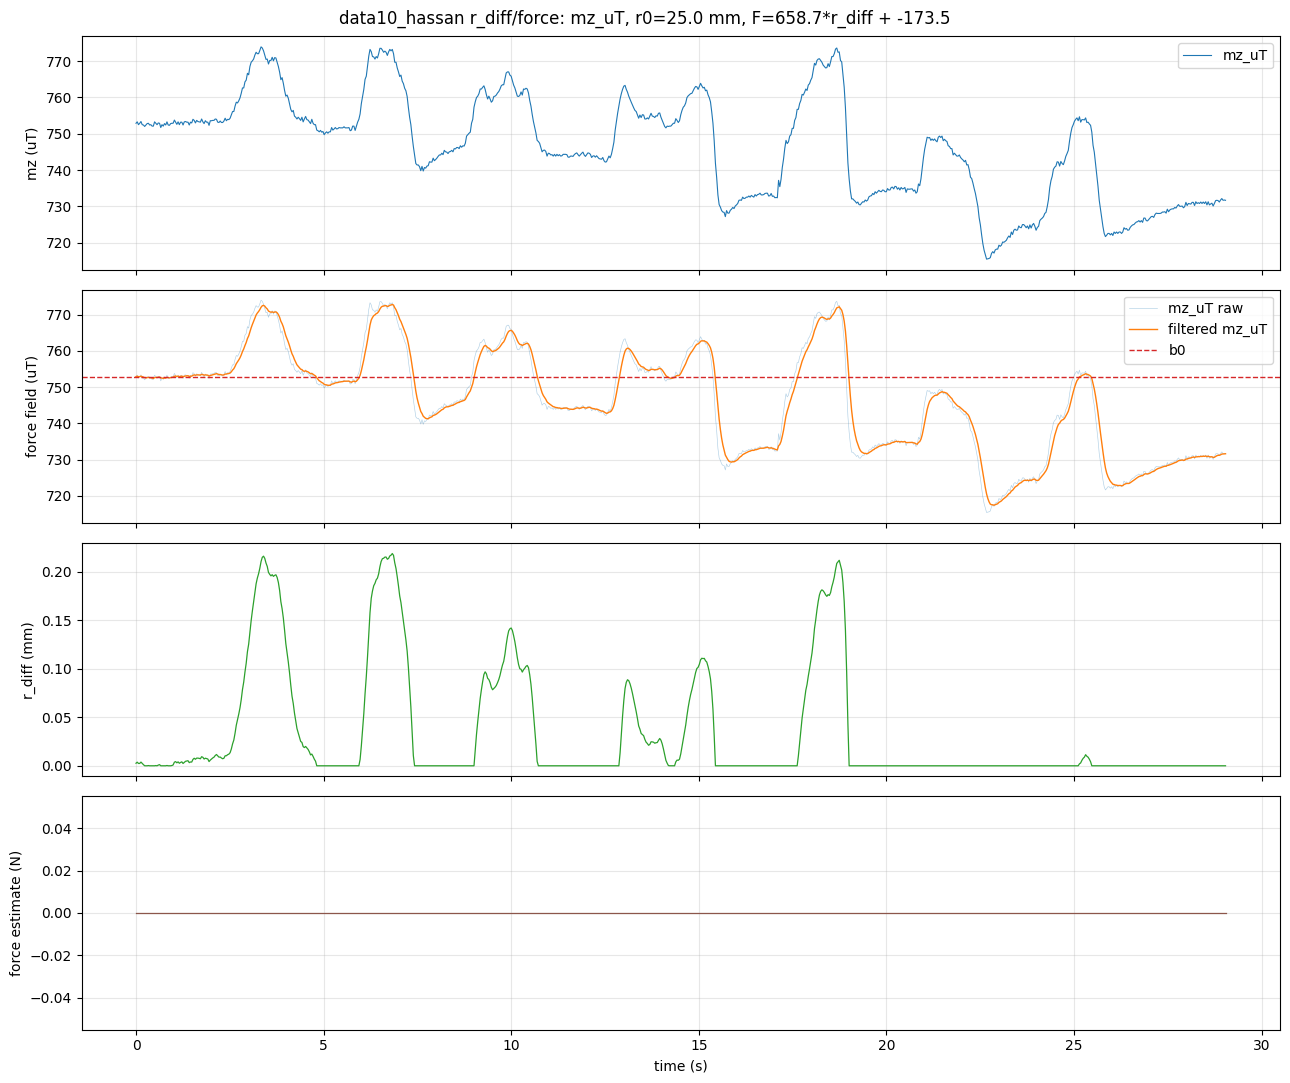

In [ ]:
# data10_hassan: magnetometer, r_diff, and force estimate
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV_PATH = Path("data10_hassan.csv")
STARTUP_BASELINE_S = 1.0
MAG_LPF_ALPHA = 0.25

# Tune these parameters.
MAG_AXIS = "mz_uT"      # choose: mx_uT, my_uT, mz_uT, or mag_norm_uT
USE_ABS_FIELD = True    # use abs(axis) for single-axis force proxy
R0_MM = 25.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5

RAW_CAPTURE_COLS = [
    "seq", "timestamp_ms",
    "ax_g", "ay_g", "az_g",
    "gx_dps", "gy_dps", "gz_dps",
    "roll_deg", "pitch_deg", "yaw_deg",
    "mx_uT", "my_uT", "mz_uT",
]
MAG_ONLY_COLS = ["seq", "timestamp_ms", "mx_uT", "my_uT", "mz_uT"]


def load_capture_csv(path):
    rows = []
    header = None
    with Path(path).open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if parts[0] == "seq":
                header = parts
                continue
            try:
                rows.append([float(p) for p in parts])
            except ValueError:
                continue

    if not rows:
        return pd.DataFrame()

    width = max(len(r) for r in rows)
    rows = [r + [np.nan] * (width - len(r)) for r in rows]

    if header and len(header) == width:
        cols = header
    elif width >= len(RAW_CAPTURE_COLS):
        cols = RAW_CAPTURE_COLS + [f"extra_{i}" for i in range(width - len(RAW_CAPTURE_COLS))]
    elif width >= len(MAG_ONLY_COLS):
        cols = MAG_ONLY_COLS + [f"extra_{i}" for i in range(width - len(MAG_ONLY_COLS))]
    else:
        cols = [f"col_{i}" for i in range(width)]

    df = pd.DataFrame(rows, columns=cols)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    return df


df_force = load_capture_csv(CSV_PATH)
if df_force.empty:
    print(f"No parseable rows in {CSV_PATH}")
elif not {"mx_uT", "my_uT", "mz_uT"}.issubset(df_force.columns):
    print(f"{CSV_PATH} does not include recognized magnetometer columns")
    display(df_force.head())
else:
    df_force["mag_norm_uT"] = np.sqrt(
        df_force["mx_uT"]**2 + df_force["my_uT"]**2 + df_force["mz_uT"]**2
    )

    field = df_force[MAG_AXIS]
    if USE_ABS_FIELD:
        field = field.abs()
    df_force["force_field_uT"] = field
    df_force["force_field_lpf_uT"] = field.ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()

    startup = df_force[df_force["time_s"] <= STARTUP_BASELINE_S]
    b0 = startup["force_field_lpf_uT"].mean()

    ratio = b0 / df_force["force_field_lpf_uT"]
    ratio = ratio.where((ratio > 0) & np.isfinite(ratio), np.nan)
    df_force["r_mm"] = R0_MM * np.cbrt(ratio)
    df_force["r_diff_mm"] = (R0_MM - df_force["r_mm"]).clip(lower=0.0)
    df_force["force_n"] = (FORCE_SLOPE * df_force["r_diff_mm"] + FORCE_INTERCEPT).clip(lower=0.0)

    display(pd.Series({
        "file": str(CSV_PATH),
        "rows": len(df_force),
        "duration_s": df_force["time_s"].iloc[-1],
        "mag_axis_for_force": MAG_AXIS,
        "use_abs_field": USE_ABS_FIELD,
        "b0_force_field_uT": b0,
        "R0_MM": R0_MM,
        "FORCE_SLOPE": FORCE_SLOPE,
        "FORCE_INTERCEPT": FORCE_INTERCEPT,
        "max_r_diff_mm": df_force["r_diff_mm"].max(),
        "max_force_n": df_force["force_n"].max(),
        "mean_force_n": df_force["force_n"].mean(),
    }, name="data10 force params/summary"))

    fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

    axs[0].plot(df_force["time_s"], df_force["mz_uT"], lw=0.8, label="mz_uT")
    axs[0].set_ylabel("mz (uT)")
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(df_force["time_s"], df_force["force_field_uT"], lw=0.45, alpha=0.35, label=f"{MAG_AXIS} raw")
    axs[1].plot(df_force["time_s"], df_force["force_field_lpf_uT"], lw=1.0, label=f"filtered {MAG_AXIS}")
    axs[1].axhline(b0, color="C3", ls="--", lw=1.0, label="b0")
    axs[1].set_ylabel("force field (uT)")
    axs[1].legend(loc="upper right")
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(df_force["time_s"], df_force["r_diff_mm"], lw=0.9, color="C2")
    axs[2].set_ylabel("r_diff (mm)")
    axs[2].grid(True, alpha=0.3)

    axs[3].plot(df_force["time_s"], df_force["force_n"], lw=0.9, color="C5")
    axs[3].set_ylabel("force estimate (N)")
    axs[3].set_xlabel("time (s)")
    axs[3].grid(True, alpha=0.3)

    fig.suptitle(
        f"data10_hassan r_diff/force: {MAG_AXIS}, r0={R0_MM} mm, "
        
        f"F={FORCE_SLOPE}*r_diff + {FORCE_INTERCEPT}"
    )
    plt.tight_layout()
    plt.show()
